# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
diabetes_numpy = load_diabetes(as_frame=False)
print(diabetes_numpy.data[:1])

[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]]


In [4]:
diabetes_pandas = load_diabetes(as_frame=True)
print(diabetes_pandas.data.head(1))

        age      sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.05068  0.061696  0.021872 -0.044223 -0.034821 -0.043401   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  


In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [5]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
100,0.016281,-0.044642,0.017506,-0.022885,0.060349,0.044406,0.030232,-0.002592,0.037236,-0.001078,128.0
308,0.001751,-0.044642,-0.046085,-0.033213,-0.073119,-0.081480,0.044958,-0.069383,-0.061176,-0.079778,114.0
136,-0.092695,-0.044642,-0.081653,-0.057313,-0.060735,-0.068014,0.048640,-0.076395,-0.066490,-0.021788,85.0
248,-0.041840,-0.044642,0.047685,0.059744,0.127771,0.128016,-0.024993,0.108111,0.063890,0.040343,258.0
57,-0.027310,-0.044642,-0.063330,-0.050427,-0.089630,-0.104340,0.052322,-0.076395,-0.056153,-0.067351,37.0
243,0.016281,0.050680,-0.046085,0.011544,-0.033216,-0.016032,-0.010266,-0.002592,-0.043984,-0.042499,47.0
265,-0.034575,0.050680,-0.025607,-0.017135,0.001183,-0.002880,0.008142,-0.015508,0.014821,0.040343,74.0
402,0.110727,0.050680,-0.033151,-0.022885,-0.004321,0.020293,-0.061809,0.071210,0.015568,0.044485,168.0
338,-0.063635,-0.044642,-0.033151,-0.033213,0.001183,0.024051,-0.024993,-0.002592,-0.022517,-0.059067,214.0
322,0.023546,0.050680,0.061696,0.062050,0.024574,-0.036073,-0.091262,0.155345,0.133397,0.081764,242.0


In [6]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [11]:
# 1. Conteo de nulos por columna
print("Conteo de valores nulos:")
print(data.isnull().sum())

# 2. Porcentaje para toma de decisiones
print("\nPorcentaje de nulos:")
print((data.isnull().sum() / len(data)) * 100)

Conteo de valores nulos:
age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

Porcentaje de nulos:
age       0.000000
sex       0.000000
bmi       9.954751
bp        9.954751
s1        0.000000
s2        0.000000
s3        0.000000
s4        0.000000
s5        0.000000
s6        0.000000
target    0.000000
dtype: float64


### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [12]:
#Crear el objeto imputador
imputer_simple = SimpleImputer(strategy='mean')

# Aplica la imputación (Fit + Transform)
# Nota: reshape (-1, 1) es necesario porque el imputer espera una matriz 2D
data['bmi_simple'] = imputer_simple.fit_transform(data[['bmi']])

print("Nulos en bmi_simple despues de la imputación:", data['bmi_simple'].isnull().sum())

Nulos en bmi_simple despues de la imputación: 0


### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [13]:
# Crear el objeto KNNImputer
# n_neighbors=5 significa que mirará a los 5 pacientes más parecidos para decidir el valor
knn_imputer = KNNImputer(n_neighbors=5)

# Aplicamos a todo el dataset (o a las columnas numéricas)
# El KNN necesita ver las otras columnas para encontrar "parecidos"
data_imputed = knn_imputer.fit_transform(data)

# Convertimos el resultado (que es un array de numpy) de vuelta a DataFrame
data_final = pd.DataFrame(data_imputed, columns=data.columns)

print("Nulos en bp después de KNN:", data_final['bp'].isnull().sum())

Nulos en bp después de KNN: 0


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

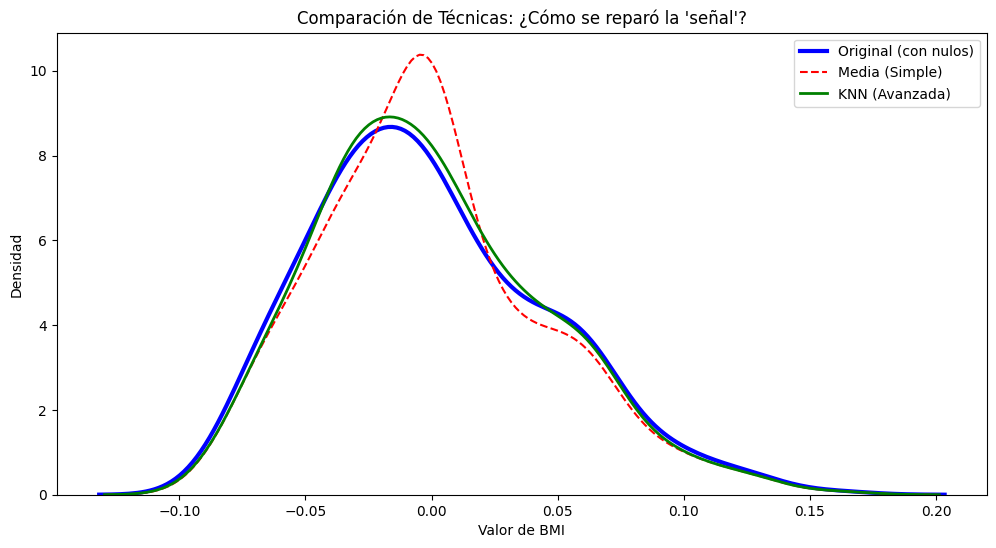

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el lienzo
plt.figure(figsize=(12, 6))

# 1. Datos Originales (La señal base)
sns.kdeplot(data['bmi'], label="Original (con nulos)", color="blue", lw=3)

# 2. Imputación Simple (Media)
sns.kdeplot(data['bmi_simple'], label="Media (Simple)", color="red", linestyle="--")

# 3. Imputación KNN (Para comparar, necesitamos extraerla del dataframe imputado que hicimos antes)
# Usaremos la columna 'bmi' del dataframe que procesó el KNNImputer
sns.kdeplot(data_final['bmi'], label="KNN (Avanzada)", color="green", lw=2)

plt.title("Comparación de Técnicas: ¿Cómo se reparó la 'señal'?")
plt.xlabel("Valor de BMI")
plt.ylabel("Densidad")
plt.legend()
plt.show()